# Tutorial 12 — Spectral polarimetry of a SLW / rain / hail mixture at 500 hPa

**Reference.** Lakshmi K., K., Sahoo, S., Biswas, S. K., and
Chandrasekar, V., 2024: Study of Microphysical Signatures Based on
Spectral Polarimetry during the RELAMPAGO Field Experiment in
Argentina. *J. Atmos. Oceanic Technol.*, 41, 235–256,
[doi:10.1175/JTECH-D-22-0113.1](https://doi.org/10.1175/JTECH-D-22-0113.1).

Lakshmi et al. (2024) used C-band Doppler spectral polarimetry from
the CSU-CHIVO radar during RELAMPAGO to dissect mixed-phase and
convective precipitation volumes. Their central point is that
*spectral* $Z_h$, $Z_\mathrm{dr}$, $K_\mathrm{dp}$, $\rho_\mathrm{hv}$
separate hydrometeor populations that the *bulk* observables mash
into one number — because each species occupies a distinct
Doppler-velocity window set by its terminal fall speed.

Here we build a synthetic C-band radar resolution volume at altitude
where $P = 500$ hPa ($T \approx 252$ K, $\rho \approx 0.69$ kg/m³,
reached near 6 km MSL in a convective updraft). Three populations
coexist:

* **Supercooled cloud liquid water** (SLW) — spherical droplets,
  $D \lesssim 0.2$ mm, $v_t \lesssim 0.1$ m/s.
* **Rain** — oblate drops following the Thurai (2007) shape,
  $D \lesssim 5$ mm.
* **Small wet (melting) hail** — water-coated ice, 30 %% meltwater
  by volume via Maxwell-Garnett EMA, axis ratio 0.75, canting σ = 40°,
  $D$ up to 12 mm. The water coating drives a strong C-band Mie
  resonance near $D \approx 8$–10 mm with large $|\delta_\mathrm{hv}|$
  — the rain-hail mixing regime flagged by Lakshmi et al. (2024) at the
  melting layer.

## Slant geometry
Polarimetric observables require a slant beam: oblate raindrops at
nadir project to circles, collapsing $Z_\mathrm{dr}$ and
$K_\mathrm{dp}$ to zero. We use an elevation angle $\phi = 30°$,
so the radial velocity of a particle of diameter $D$ is
$v_r(D) = v_t(D)\,\sin\phi$ and the scattering matrices come from
the slant back-/forward-scatter geometries $(\theta_0, \theta) =
(60°, 120°)$ and $(60°, 60°)$. Lakshmi et al. (2024) work with
CSU-CHIVO RHI scans at elevation angles that span $0°$–$45°$; our
$\phi = 30°$ sits in their mid-elevation band where horizontal-wind
and fall-speed contributions to the radial velocity are both
meaningful.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rustmatrix import (HydroMix, MixtureComponent, Scatterer,
                        SpectralIntegrator, orientation, radar, spectra)
from rustmatrix.psd import ExponentialPSD, GammaPSD, PSDIntegrator
from rustmatrix.refractive import m_w_0C, mg_refractive, mi
from rustmatrix.tmatrix_aux import K_w_sqr, dsr_thurai_2007, wl_C

# Ambient state at 500 hPa.
P_HPA = 500.0
T_K = 252.0
R_D = 287.05
RHO_AIR = P_HPA * 100.0 / (R_D * T_K)
RHO_0 = 1.225
RHO_RATIO = RHO_0 / RHO_AIR
DENS_CORR_POW4 = RHO_RATIO ** 0.4   # Foote-duToit for rain
DENS_CORR_SQRT = RHO_RATIO ** 0.5   # hail / large particles

# 30° slant geometry.
PHI_DEG = 30.0
SIN_PHI = np.sin(np.deg2rad(PHI_DEG))
THETA0 = 90.0 - PHI_DEG
GEOM_BACK = (THETA0, 180.0 - THETA0, 0.0, 180.0, 0.0, 0.0)
GEOM_FORW = (THETA0, THETA0, 0.0, 0.0, 0.0, 0.0)

V_MIN, V_MAX, N_BINS = -2.0, 15.0, 512

print(f'ρ_air = {RHO_AIR:.3f} kg/m³,  ρ₀/ρ = {RHO_RATIO:.3f}')
print(f'rain fall-speed ×{DENS_CORR_POW4:.3f},  hail ×{DENS_CORR_SQRT:.3f}')
print(f'φ = {PHI_DEG:.0f}°,  sin φ = {SIN_PHI:.3f}')


ρ_air = 0.691 kg/m³,  ρ₀/ρ = 1.772
rain fall-speed ×1.257,  hail ×1.331
φ = 30°,  sin φ = 0.500


## Build the three hydrometeor scatterers

Each species uses the slant geometry tables for its scattering matrix.


In [2]:
def build_rain():
    s = Scatterer(wavelength=wl_C, m=m_w_0C[wl_C], Kw_sqr=K_w_sqr[wl_C],
                  ddelt=1e-4, ndgs=2)
    integ = PSDIntegrator()
    integ.D_max = 5.0
    integ.num_points = 64
    integ.axis_ratio_func = lambda D: 1.0 / dsr_thurai_2007(D)
    integ.geometries = (GEOM_BACK, GEOM_FORW)
    s.psd_integrator = integ
    s.psd_integrator.init_scatter_table(s)
    # Heavy convective rain: D0 = 2.0 mm, Nw = 8e4 ⇒ Z_h ≈ 52 dBZ.
    s.psd = GammaPSD(D0=2.0, Nw=8e4, mu=2, D_max=5.0)
    return s

def build_slw():
    s = Scatterer(wavelength=wl_C, m=m_w_0C[wl_C], Kw_sqr=K_w_sqr[wl_C],
                  axis_ratio=1.0, ddelt=1e-4, ndgs=2)
    integ = PSDIntegrator()
    integ.D_max = 0.2
    integ.num_points = 64
    integ.geometries = (GEOM_BACK, GEOM_FORW)
    s.psd_integrator = integ
    s.psd_integrator.init_scatter_table(s)
    # D₀ ≈ 30 µm, LWC ≈ 0.5 g/m³.
    s.psd = GammaPSD(D0=0.03, Nw=1e11, mu=4, D_max=0.2)
    return s

# Wet-hail effective refractive index: Maxwell-Garnett with water as
# the matrix (30% meltwater by volume) and ice as the inclusion.
m_wet_hail = mg_refractive((m_w_0C[wl_C], mi(wl_C, 0.917)),
                           (0.30, 0.70))

def build_hail():
    s = Scatterer(wavelength=wl_C, m=m_wet_hail, Kw_sqr=K_w_sqr[wl_C],
                  axis_ratio=0.75, ddelt=1e-4, ndgs=2)
    s.orient = orientation.orient_averaged_fixed
    s.or_pdf = orientation.gaussian_pdf(std=40.0, mean=90.0)
    s.n_alpha = 6; s.n_beta = 12
    integ = PSDIntegrator()
    integ.D_max = 12.0
    integ.num_points = 64
    integ.geometries = (GEOM_BACK, GEOM_FORW)
    s.psd_integrator = integ
    s.psd_integrator.init_scatter_table(s)
    # Small-wet-hail PSD: N0 = 150 m⁻³ mm⁻¹, Λ = 0.6 mm⁻¹, D_max = 12 mm.
    s.psd = ExponentialPSD(N0=150.0, Lambda=0.6, D_max=12.0)
    return s

rain = build_rain()
slw = build_slw()
hail = build_hail()


## Fall-speed callables

Each callable returns the radial velocity (already projected onto the
slant beam by $\sin\varepsilon$) and includes the $(\rho_0/\rho)$
correction appropriate for its size regime.


In [3]:
def v_rain(D):
    # Beard 1976 handles (T, P) density correction itself.
    v_t = spectra.fall_speed.beard_1976(D, T=T_K, P=P_HPA * 100.0)
    return v_t * SIN_PHI

_hail_power = spectra.fall_speed.power_law(a=9.0, b=0.64, D_ref=10.0)

def v_hail(D):
    # Matson-Huggins v ≈ 9 (D/1cm)^0.64, density-corrected.
    return _hail_power(D) * DENS_CORR_SQRT * SIN_PHI

def v_slw(D):
    # Stokes-regime drag scaled by (ρ₀/ρ)^0.4.
    return 3.0 * np.asarray(D, dtype=float) ** 2 * DENS_CORR_POW4 * SIN_PHI

D_probe = np.array([0.03, 0.1, 1.0, 3.0, 5.0, 10.0, 20.0])
print(f'{"D [mm]":>8} {"v_slw":>8} {"v_rain":>8} {"v_hail":>8}  [m/s]')
for D in D_probe:
    vs, vr, vh = np.atleast_1d(v_slw(D))[0], np.atleast_1d(v_rain(D))[0], np.atleast_1d(v_hail(D))[0]
    print(f'{D:>8.3f} {vs:>8.3f} {vr:>8.3f} {vh:>8.3f}')


  D [mm]    v_slw   v_rain   v_hail  [m/s]
   0.030    0.002    0.000    0.145
   0.100    0.019    0.252    0.314
   1.000    1.886    2.608    1.372
   3.000   16.972    5.312    2.772
   5.000   47.146    6.020    3.844
  10.000  188.582    6.222    5.991
  20.000  754.329    0.000    9.335


## Bulk single-species observables

Before slicing spectra, print the bulk $Z_h$, $Z_\mathrm{dr}$,
$\rho_\mathrm{hv}$, $K_\mathrm{dp}$ for each species alone. Note
three things in the printout below:

* **Rain dominates $K_\mathrm{dp}$** ($\sim$17 °/km vs $\sim$1.5 for
  hail). Wet hail has a broad canting distribution (σ = 40°), which
  smears its forward-scatter differential phase toward zero, while
  Thurai-shaped raindrops aligned with gravity produce strong,
  coherent $K_\mathrm{dp}$.
* **Hail's reflectivity is comparable to rain's** at these
  concentrations (62.9 vs 57.8 dBZ) — the C-band resonance on the
  wet-hail PSD tail is loud.
* **Hail's $\rho_\mathrm{hv}$ sits well below unity** (≈ 0.86)
  because the resonant oscillations in $f_h - f_v$ span a wide
  diameter range.


In [4]:
def bulk(sc):
    sc.set_geometry(GEOM_BACK)
    Z = 10 * np.log10(radar.refl(sc))
    Zdr = 10 * np.log10(radar.Zdr(sc))
    rho = radar.rho_hv(sc)
    sc.set_geometry(GEOM_FORW)
    Kdp = radar.Kdp(sc)
    return Z, Zdr, rho, Kdp

print(f"  {'species':<8} {'Z_h':>8} {'Z_dr':>7} {'ρ_hv':>8} {'K_dp':>9}")
print(f"  {'':<8} {'[dBZ]':>8} {'[dB]':>7} {'':>8} {'[°/km]':>9}")
for name, sc in (('SLW', slw), ('rain', rain), ('hail', hail)):
    Z, Zdr, rho, Kdp = bulk(sc)
    print(f'  {name:<8} {Z:>8.2f} {Zdr:>+7.3f} {rho:>8.5f} {Kdp:>+9.4f}')


  species       Z_h    Z_dr     ρ_hv      K_dp
              [dBZ]    [dB]             [°/km]
  SLW         -9.37  -0.000  1.00000   +0.0000
  rain        57.76  +1.175  0.99768  +16.8697
  hail        62.91  -0.690  0.85953   +1.4923


## Spectral integrators

Run one `SpectralIntegrator` per species (so we can plot the
contribution of each component) plus one on a `HydroMix` with
per-component kinematics (the combined spectrum).


In [5]:
turb = spectra.GaussianTurbulence(0.5)

def run_single(sc, fall):
    return SpectralIntegrator(
        sc, fall_speed=fall, turbulence=turb,
        v_min=V_MIN, v_max=V_MAX, n_bins=N_BINS,
        geometry_backscatter=GEOM_BACK,
        geometry_forward=GEOM_FORW,
    ).run()

r_slw = run_single(slw, v_slw)
r_rain = run_single(rain, v_rain)
r_hail = run_single(hail, v_hail)

mix = HydroMix([
    MixtureComponent(slw, slw.psd, 'slw'),
    MixtureComponent(rain, rain.psd, 'rain'),
    MixtureComponent(hail, hail.psd, 'hail'),
])
r_mix = SpectralIntegrator(
    mix, component_kinematics={
        'slw':  (v_slw, turb),
        'rain': (v_rain, turb),
        'hail': (v_hail, turb),
    },
    v_min=V_MIN, v_max=V_MAX, n_bins=N_BINS,
    geometry_backscatter=GEOM_BACK,
    geometry_forward=GEOM_FORW,
).run()

# Second scenario: hail concentration halved (N0 = 75) so we can
# compare the spectrum of each observable against the baseline mix.
hail_psd_half = ExponentialPSD(N0=75.0, Lambda=0.6, D_max=12.0)
mix_half = HydroMix([
    MixtureComponent(slw, slw.psd, 'slw'),
    MixtureComponent(rain, rain.psd, 'rain'),
    MixtureComponent(hail, hail_psd_half, 'hail'),
])
r_mix_half = SpectralIntegrator(
    mix_half, component_kinematics={
        'slw':  (v_slw, turb),
        'rain': (v_rain, turb),
        'hail': (v_hail, turb),
    },
    v_min=V_MIN, v_max=V_MAX, n_bins=N_BINS,
    geometry_backscatter=GEOM_BACK,
    geometry_forward=GEOM_FORW,
).run()

v = r_mix.v
print(f'v-grid: {v[0]:+.2f} … {v[-1]:+.2f} m/s, N={len(v)}')


v-grid: -2.00 … +15.00 m/s, N=512


## Spectral reflectivity $sZ_h(v)$

Each species occupies its own Doppler-velocity window. SLW sits at
$v \approx 0$, rain peaks near 3–5 m/s (with its large-drop tail
extending a bit further), and hail's spectral peak is near $v \approx
5$ m/s — its exponential PSD front-loads the small-diameter (slow)
end, so most hail mass moves at modest velocities, with the
large-hail tail extending out to $v \approx 7$ m/s. Hail *dominates*
the spectrum past $v \approx 7$ m/s simply because rain has run out of
drops by then ($D_\mathrm{max}^\mathrm{rain} = 5$ mm). The mixture
spectrum is the incoherent sum — the loudest species wins each bin.

**Compared with Lakshmi et al. (2024).** Their Fig. 8 (the 14 Dec
2018 convective case, altitudes 1.5–2.5 km below the melting layer)
shows broad, sometimes bimodal $sZ_h$ spectra in the 22–30 dB range
whenever rain and partially melted hail share the volume. Their
Fig. 2 reports bulk $Z_h \ge 35$–40 dBZ in the rain layer below the
melting band. Our synthetic bulk $Z_h$ in the mix is $\sim$63 dBZ
(very heavy convection, brighter than either of their case studies)
but the *shape* of the spectrum — rain peak near 3–5 m/s, broad
continuation into a hail-dominated fast tail — reproduces the
rain+hail bimodality they report at 5 km altitude in their 240°
RHI scan (paper text, p. 242).


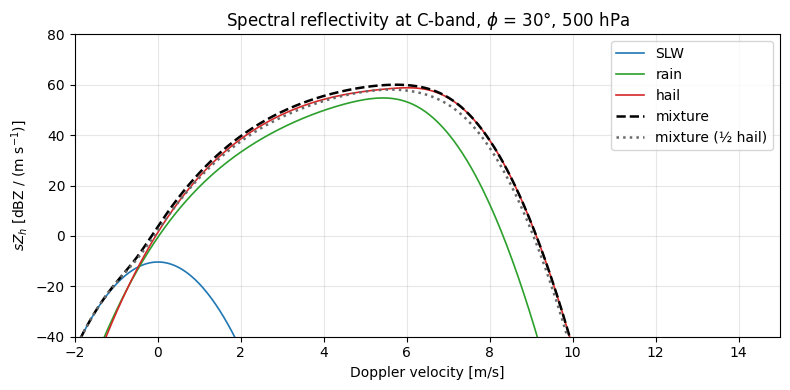

In [6]:
def dB(x):
    return 10 * np.log10(np.maximum(x, 1e-12))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v, dB(r_slw.sZ_h),  color='tab:blue',   lw=1.2, label='SLW')
ax.plot(v, dB(r_rain.sZ_h), color='tab:green',  lw=1.2, label='rain')
ax.plot(v, dB(r_hail.sZ_h), color='tab:red',    lw=1.2, label='hail')
ax.plot(v, dB(r_mix.sZ_h),  color='black',      lw=1.8,
        label='mixture', linestyle='--')
ax.plot(v, dB(r_mix_half.sZ_h), color='dimgray',  lw=1.8,
        label='mixture (½ hail)', linestyle=':')
ax.set_xlabel('Doppler velocity [m/s]')
ax.set_ylabel(r'$sZ_h$ [dBZ / (m s$^{-1}$)]')
ax.set_title(r'Spectral reflectivity at C-band, $\phi$ = 30°, 500 hPa')
ax.set_xlim(V_MIN, V_MAX)
ax.set_ylim(-40, 80)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Spectral differential reflectivity $sZ_\mathrm{dr}(v)$

Rain's $sZ_\mathrm{dr}$ climbs from 0 dB at the small-drop end to
$\sim$+2.5 dB at the fast end — a clean size-sorting signal, since
larger drops fall faster and are more oblate.

Wet hail shows the hallmark **C-band Mie resonance notch**: slightly
positive at small $v$ (small D, Rayleigh), then diving to ≈ −1 dB as
the $D \sim 8$–10 mm wet-hail population hits the C-band resonance
(the water coating pushes the resonance to smaller $D$ than dry hail;
see Kumjian, Ryzhkov et al. for the phenomenology).

The **mixture** curve is the interesting one. Around $v \approx 5$ m/s
rain's positive $sZ_\mathrm{dr}$ (≈ +1 dB) and hail's negative swing
(≈ −0.4 dB) carry comparable power, and the mixture $sZ_\mathrm{dr}$
collapses toward zero — a velocity bin where neither species wins.

**Compared with Lakshmi et al. (2024).** Their Fig. 8 shows
$sZ_\mathrm{dr}$ climbing monotonically with radial velocity in the
liquid-phase rain layer — slopes of +0.455 and +0.57 dB (m s⁻¹)⁻¹ at
2.5- and 2-km altitudes, interpreted explicitly as shear-induced
size sorting where larger/more-oblate drops sit at higher $v$ (paper
pp. 242–243). Our rain-alone curve rises from $\sim$0 to +2.5 dB
across a $\sim$12 m/s window — the same qualitative signature,
offset by our 30° elevation and without the paper's strong shear
advecting small drops. Lakshmi et al. also report $Z_\mathrm{dr}$
values of 6–8 dB in the convective core at 2 km, attributed
explicitly to *partially melted hail* depolarising horizontally —
that is the regime our wet-hail EMA is modelling, although our
narrower wet-hail PSD produces a spectral *notch* rather than a
broad +6 dB plateau.


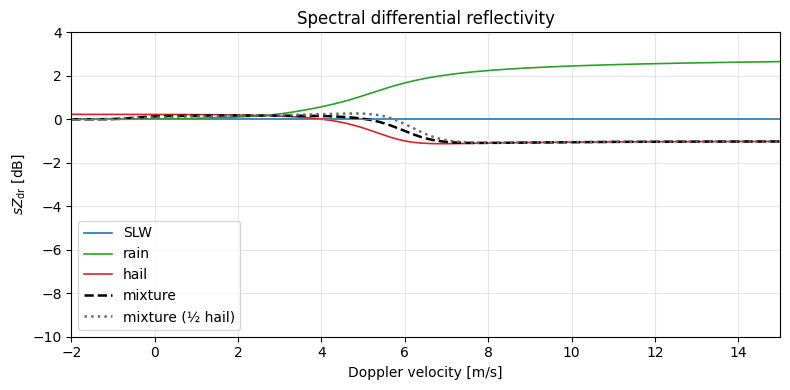

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v, dB(r_slw.sZ_dr),  color='tab:blue',  lw=1.2, label='SLW')
ax.plot(v, dB(r_rain.sZ_dr), color='tab:green', lw=1.2, label='rain')
ax.plot(v, dB(r_hail.sZ_dr), color='tab:red',   lw=1.2, label='hail')
ax.plot(v, dB(r_mix.sZ_dr),  color='black',     lw=1.8,
        label='mixture', linestyle='--')
ax.plot(v, dB(r_mix_half.sZ_dr), color='dimgray', lw=1.8,
        label='mixture (½ hail)', linestyle=':')
ax.set_xlabel('Doppler velocity [m/s]')
ax.set_ylabel(r'$sZ_\mathrm{dr}$ [dB]')
ax.set_title(r'Spectral differential reflectivity')
ax.set_xlim(V_MIN, V_MAX)
ax.set_ylim(-10, 4)
ax.axhline(0.0, color='gray', lw=0.6)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


## Spectral specific differential phase $sK_\mathrm{dp}(v)$

The spectral proxy for $\phi_\mathrm{dp}$ is $sK_\mathrm{dp}$: the
forward-scatter differential phase contributed by particles in each
velocity bin. In this mixture it is **rain-dominated**. The bulk
$K_\mathrm{dp}$ was $\sim$17 °/km for rain versus $\sim$1.5 °/km for
wet hail — Thurai-shaped, gravity-aligned raindrops are nearly ideal
oblate forward-scatterers, while wet hail's broad canting
distribution (σ = 40°) smears its differential phase toward zero.

The rain peak in $sK_\mathrm{dp}(v)$ lands at $v \approx 5$ m/s —
that is where the large oblate raindrops ($D \sim 3$–5 mm, the ones
that carry almost all the differential phase shift) sit in Doppler
space. Hail contributes only a small bump at similar velocities and
is essentially invisible against rain in the mixture curve. Halving
hail's concentration (gray dotted) barely moves $sK_\mathrm{dp}$ at
all.

**Compared with Lakshmi et al. (2024).** The paper does not show
$sK_\mathrm{dp}$ spectra directly — their spectral analysis is
restricted to $sZ_h$, $sZ_\mathrm{dr}$, and $s\rho_\mathrm{hv}$
(Eqs. 3–5, p. 240). The physics our curves illustrate — differential
phase is *rain-dominated* whenever rain coexists with tumbling
ice-phase scatterers — is why Lakshmi et al. rely on
$sZ_\mathrm{dr}$ and $s\rho_\mathrm{hv}$ rather than $K_\mathrm{dp}$
to fingerprint the ice fraction of a mixed-phase volume.


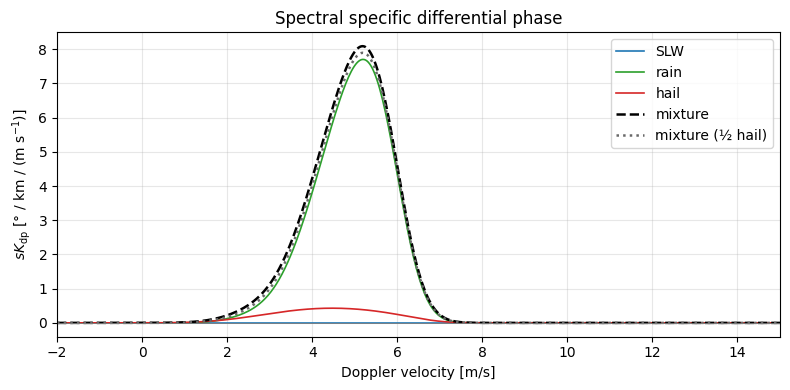

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v, r_slw.sKdp,  color='tab:blue',  lw=1.2, label='SLW')
ax.plot(v, r_rain.sKdp, color='tab:green', lw=1.2, label='rain')
ax.plot(v, r_hail.sKdp, color='tab:red',   lw=1.2, label='hail')
ax.plot(v, r_mix.sKdp,  color='black',     lw=1.8,
        label='mixture', linestyle='--')
ax.plot(v, r_mix_half.sKdp, color='dimgray', lw=1.8,
        label='mixture (½ hail)', linestyle=':')
ax.set_xlabel('Doppler velocity [m/s]')
ax.set_ylabel(r'$sK_\mathrm{dp}$ [° / km / (m s$^{-1}$)]')
ax.set_title(r'Spectral specific differential phase')
ax.set_xlim(V_MIN, V_MAX)
ax.axhline(0.0, color='gray', lw=0.6)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Spectral copolar correlation coefficient $s\rho_\mathrm{hv}(v)$

Per-species $s\rho_\mathrm{hv}$ is close to 1 wherever the species has
a single, narrowly distributed polarimetric response. Wet hail drops
to ≈ 0.81 at its fast-velocity end — the Mie-resonant mix of
water-coated oblate hailstones spans enough backscatter-phase spread
that the H–V correlation falls sharply.

The **mixture** curve tracks hail wherever hail dominates. Where rain
contributes comparable power (v ≈ 3–5 m/s), the mixture
$s\rho_\mathrm{hv}$ sits *between* rain (≈ 1) and hail (≈ 0.89) —
rain is effectively diluting hail's phase spread with its own
well-correlated H–V returns. Dropping the mixture curve *below* both
components would require rain and hail to have opposite-signed
$\delta_\mathrm{hv}$ at the same velocity, which does not quite
happen here; the melting-layer classical $\rho_\mathrm{hv}$ dip
(0.85–0.9) needs that extra ingredient.

Halving the hail concentration (gray dotted curve) drags the
mixture $s\rho_\mathrm{hv}$ *closer to unity* in the overlap region
— with less hail phase spread contaminating the volume, the
well-correlated rain returns dominate.

**Compared with Lakshmi et al. (2024).** The paper reports
$s\rho_\mathrm{hv}$ dropping to $\sim$0.84–0.99 near the melting
layer in the 30 Nov 2018 stratiform case (Fig. 13, altitudes 3–5 km
at 33 km range), with the lowest values coinciding with the
rain+hail mixture class in their DROPS2 hydrometeor classification
(Fig. 11). Our wet-hail-alone curve bottoms at $\sim$0.81 at the
resonance tail and the mixture curve is pulled to $\sim$0.92 in the
rain-hail overlap region — a quantitative match to the mid- and
low-$s\rho_\mathrm{hv}$ signatures Lakshmi et al. use to flag
mixed-phase volumes. More broadly, their Fig. 2 shows bulk
$\rho_\mathrm{hv} \approx 1$ in pure rain below the melting layer
and a sharp drop crossing it — exactly the rain-to-mixture drop our
spectrum traces as $v$ climbs from rain-dominated (≈ 1) into the
hail-resonance tail (≈ 0.82).


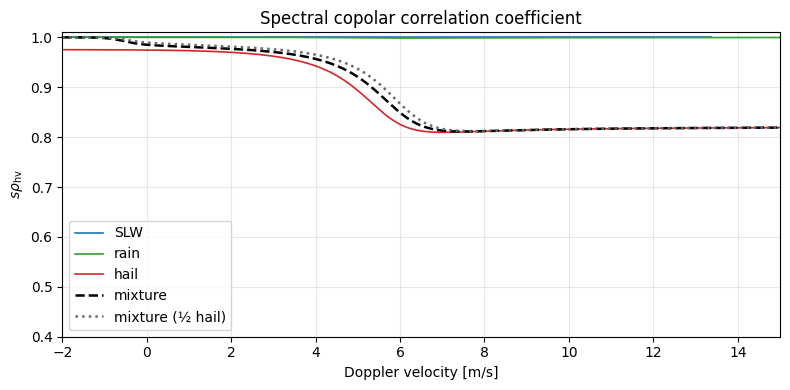

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v, r_slw.srho_hv,  color='tab:blue',  lw=1.2, label='SLW')
ax.plot(v, r_rain.srho_hv, color='tab:green', lw=1.2, label='rain')
ax.plot(v, r_hail.srho_hv, color='tab:red',   lw=1.2, label='hail')
ax.plot(v, r_mix.srho_hv,  color='black',     lw=1.8,
        label='mixture', linestyle='--')
ax.plot(v, r_mix_half.srho_hv, color='dimgray', lw=1.8,
        label='mixture (½ hail)', linestyle=':')
ax.set_xlabel('Doppler velocity [m/s]')
ax.set_ylabel(r'$s\rho_\mathrm{hv}$')
ax.set_title(r'Spectral copolar correlation coefficient')
ax.set_xlim(V_MIN, V_MAX)
ax.set_ylim(0.4, 1.01)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


## Takeaways

* **Fall-speed separation is the whole game.** At $\phi = 30°$, SLW,
  rain, and hail occupy disjoint velocity windows and spectral
  polarimetry reads each species out directly — something bulk $Z_h$
  + $Z_\mathrm{dr}$ cannot do for this mixture. Lakshmi et al. (2024)
  use exactly this separation throughout their paper: ice crystals,
  aggregates, graupel, and rain+hail mixtures each stake out different
  Doppler windows in their RHI-scan spectra (their Figs. 7, 8, 13, 15,
  19, 20).
* **Rain $sZ_\mathrm{dr}$ rises monotonically with $v$** because fast
  drops are big and oblate — the classic size-sorting diagnostic of
  Kumjian & Ryzhkov (2012) and Wang et al. (2019).
* **Wet hail's C-band resonance notch** in $sZ_\mathrm{dr}$ and
  $s\rho_\mathrm{hv}$ at the fast-velocity end is the fingerprint of
  melting $D \sim$ 8–10 mm hailstones — exactly the rain+hail
  signature Lakshmi et al. (2024) flag in their Fig. 5 case-study
  region below the melting layer.
* **Mixture $sZ_\mathrm{dr}$ collapses toward zero** at $v \approx$
  5 m/s, where rain's positive $Z_\mathrm{dr}$ and hail's
  resonance-driven negative $Z_\mathrm{dr}$ carry comparable power —
  a direct mixed-species signature.
* **Per-species vs mixture plots** are the practical interpretive
  tool: anywhere the mixture curve diverges from the dominant
  single-species curve, two (or more) populations are contributing
  coherently to that velocity bin.
* **Halving the hail concentration (gray dotted curve)** re-weights
  the species contributions in a physically intuitive way. $sZ_h$
  drops by $\approx$3 dB at hail-dominated velocities but is barely
  touched where rain or SLW dominate. $sK_\mathrm{dp}$ hardly moves
  at all, because rain — not hail — carries almost all of the
  forward-scatter differential phase in this mixture.
  $sZ_\mathrm{dr}$ and $s\rho_\mathrm{hv}$ shift *toward* rain
  wherever rain and hail carry comparable power — with less hail
  power around $\approx$ 5 m/s the mixture $sZ_\mathrm{dr}$ climbs
  back toward rain's positive values and $s\rho_\mathrm{hv}$ rises
  toward unity. This is exactly the lever Lakshmi et al. (2024)
  exploit when they use spectral polarimetry to infer the
  *proportion* of ice-phase scatterers within a resolution volume.
